# Defining Mode Sources and Monitors in BEAMZ

This notebook mirrors the workflow of the Tidy3D modal-source/modal-monitor tutorial using BEAMZ's cleaner simulation API: centered structures, semantic monitors, `ModeSolver.to_source()`, and named run results.

## Setup

Use the sibling `beamz-1` checkout so the notebook exercises the local API changes.

In [1]:
from pathlib import Path
import inspect
import sys

local_beamz = None
for candidate in (Path.cwd().resolve().parent / "beamz-1", Path.cwd().resolve().parent.parent / "beamz-1"):
    if (candidate / "beamz").is_dir():
        local_beamz = candidate.resolve()
        break
if local_beamz is None:
    raise RuntimeError("Could not find local BEAMZ checkout at ../beamz-1 or ../../beamz-1")
sys.path = [str(local_beamz)] + [p for p in sys.path if p and Path(p).resolve() != local_beamz]
for name in list(sys.modules):
    if name == "beamz" or name.startswith("beamz."):
        del sys.modules[name]

import beamz as bz

print(f"Using local BEAMZ checkout: {local_beamz}")
print(bz.__file__)
print(inspect.getfile(bz.Simulation))

import matplotlib.pyplot as plt
import numpy as np

plt.rcParams.update({"figure.dpi": 120})

Using local BEAMZ checkout: /Users/quentinwach/Code/beamz-1
/Users/quentinwach/Code/beamz-1/beamz/__init__.py
/Users/quentinwach/Code/beamz-1/beamz/simulation/core.py


## Geometry, Band, and Grid

Coordinates are centered on the simulation domain, matching the mental model used by Tidy3D examples.

In [2]:
um = bz.um

wg_height = 0.22 * um
wg_width = 0.45 * um
si_eps = 3.48**2
sio2_eps = 1.45**2

lambda0 = 1.55 * um
freq0 = bz.LIGHT_SPEED / lambda0
fwidth = freq0 / 10
nfreqs = 17
freqs = np.linspace(freq0 - 2 * fwidth, freq0 + 2 * fwidth, nfreqs)
lambdas_um = bz.LIGHT_SPEED / freqs / um
fcent_ind = nfreqs // 2

sim_size = (8.0 * um, 7.0 * um, 6.0 * um)
pml_t = 1.25 * um
src_x = -2.0 * um
out_x = 2.0 * um
plane_size = (0.0, 3.0 * um, 2.0 * um)
run_time = 20 / fwidth

mode_spec = bz.ModeSpec(num_modes=3, target_neff=0.98 * np.sqrt(si_eps))
source_polarization = "te"
grid_spec = bz.GridSpec.auto(min_steps_per_wvl=8, wavelength=lambda0)
source_time = bz.GaussianPulse(freq0=freq0, fwidth=fwidth)
boundary_spec = bz.BoundarySpec.all_sides(bz.PML(thickness=pml_t, formulation="cpml"))

## Structures and Monitors

The straight waveguide setup is now just materials, centered boxes, source/monitor planes, and semantic monitor classes.

In [3]:
mat_wg = bz.Medium(permittivity=si_eps)
mat_sub = bz.Medium(permittivity=sio2_eps)

substrate = bz.Structure(
    geometry=bz.Box(center=(0, 0, -0.5 * sim_size[2]), size=(bz.inf, bz.inf, sim_size[2])),
    medium=mat_sub,
)
waveguide = bz.Structure(
    geometry=bz.Box(center=(0, 0, 0.5 * wg_height), size=(bz.inf, wg_width, wg_height)),
    medium=mat_wg,
)

src_plane = bz.Box(center=(src_x, 0, 0.0), size=plane_size)
field_mnt = bz.FieldMonitor(
    center=(0, 0, 0.5 * wg_height),
    size=(sim_size[0], sim_size[1], 0.0),
    freqs=[freq0],
    components=("Ey",),
    name="field",
)
flux_mnt = bz.FluxMonitor(center=(out_x, 0, 0.0), size=plane_size, freqs=freqs, name="flux")
mode_mnt = bz.ModeMonitor(
    center=(out_x, 0, 0.0),
    size=plane_size,
    freqs=freqs,
    mode_spec=mode_spec,
    name="mode",
    direction="+x",
    polarization="te",
    record_fields=False,
)

## Build and Inspect the Straight Simulation

● Done: Raster cache hit (3d): 24393a553437887c3fbf6bbadda0453571de9c4f7e287af673a36a31f2855b38.npz | load=0.12s
dx = 0.056 um, steps = 9742


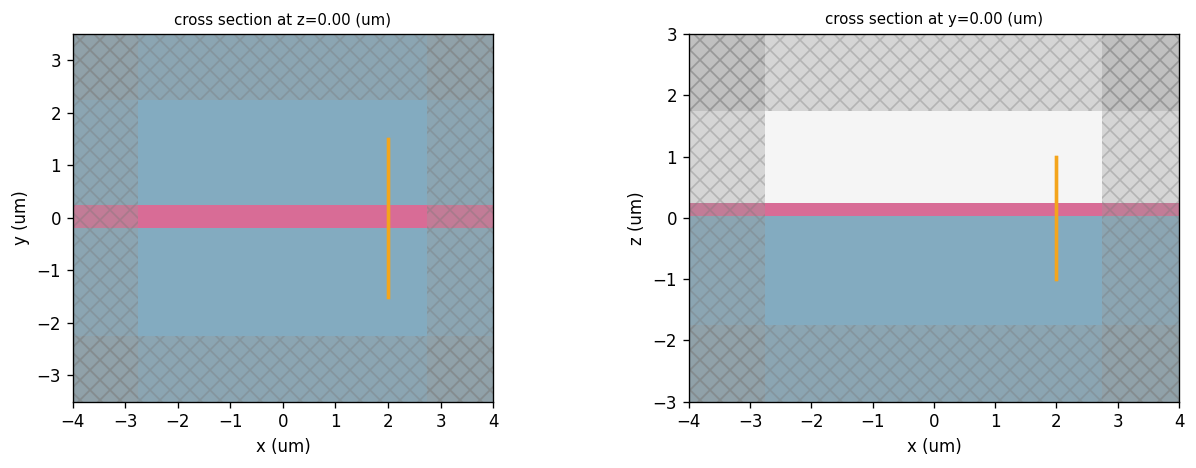

In [4]:
sim0 = bz.Simulation(
    size=sim_size,
    grid_spec=grid_spec,
    structures=[substrate, waveguide],
    sources=[],
    monitors=[field_mnt, flux_mnt, mode_mnt],
    boundary_spec=boundary_spec,
    run_time=run_time,
)
print(f"dx = {sim0.resolution / um:.3f} um, steps = {sim0.num_steps}")
fig, axes = sim0.plot(z=0.0, y=0.0, show=False)
plt.show()

## Solve Modes and Create the Mode Source

`ModeSolver` owns the mode solve, visualization, dataframe summary, and source creation.

wavelength     n eff         k eff  loss (dB/cm)  \
f            mode_index                                                     
1.934145e+14 0                 1.55  2.292638  0.000000e+00  0.000000e+00   
             1                 1.55  1.555285  3.963092e-17  1.395393e-11   
             2                 1.55  1.362922  0.000000e+00  0.000000e+00   

                         TE (Ey) fraction  wg TE fraction  wg TM fraction  \
f            mode_index                                                     
1.934145e+14 0                   0.965675        0.555119        0.005951   
             1                   0.068589        0.044074        0.071216   
             2                   0.011589        0.022764        0.009914   

                         mode area  
f            mode_index             
1.934145e+14 0            0.143408  
             1            0.437427  
             2            1.635246

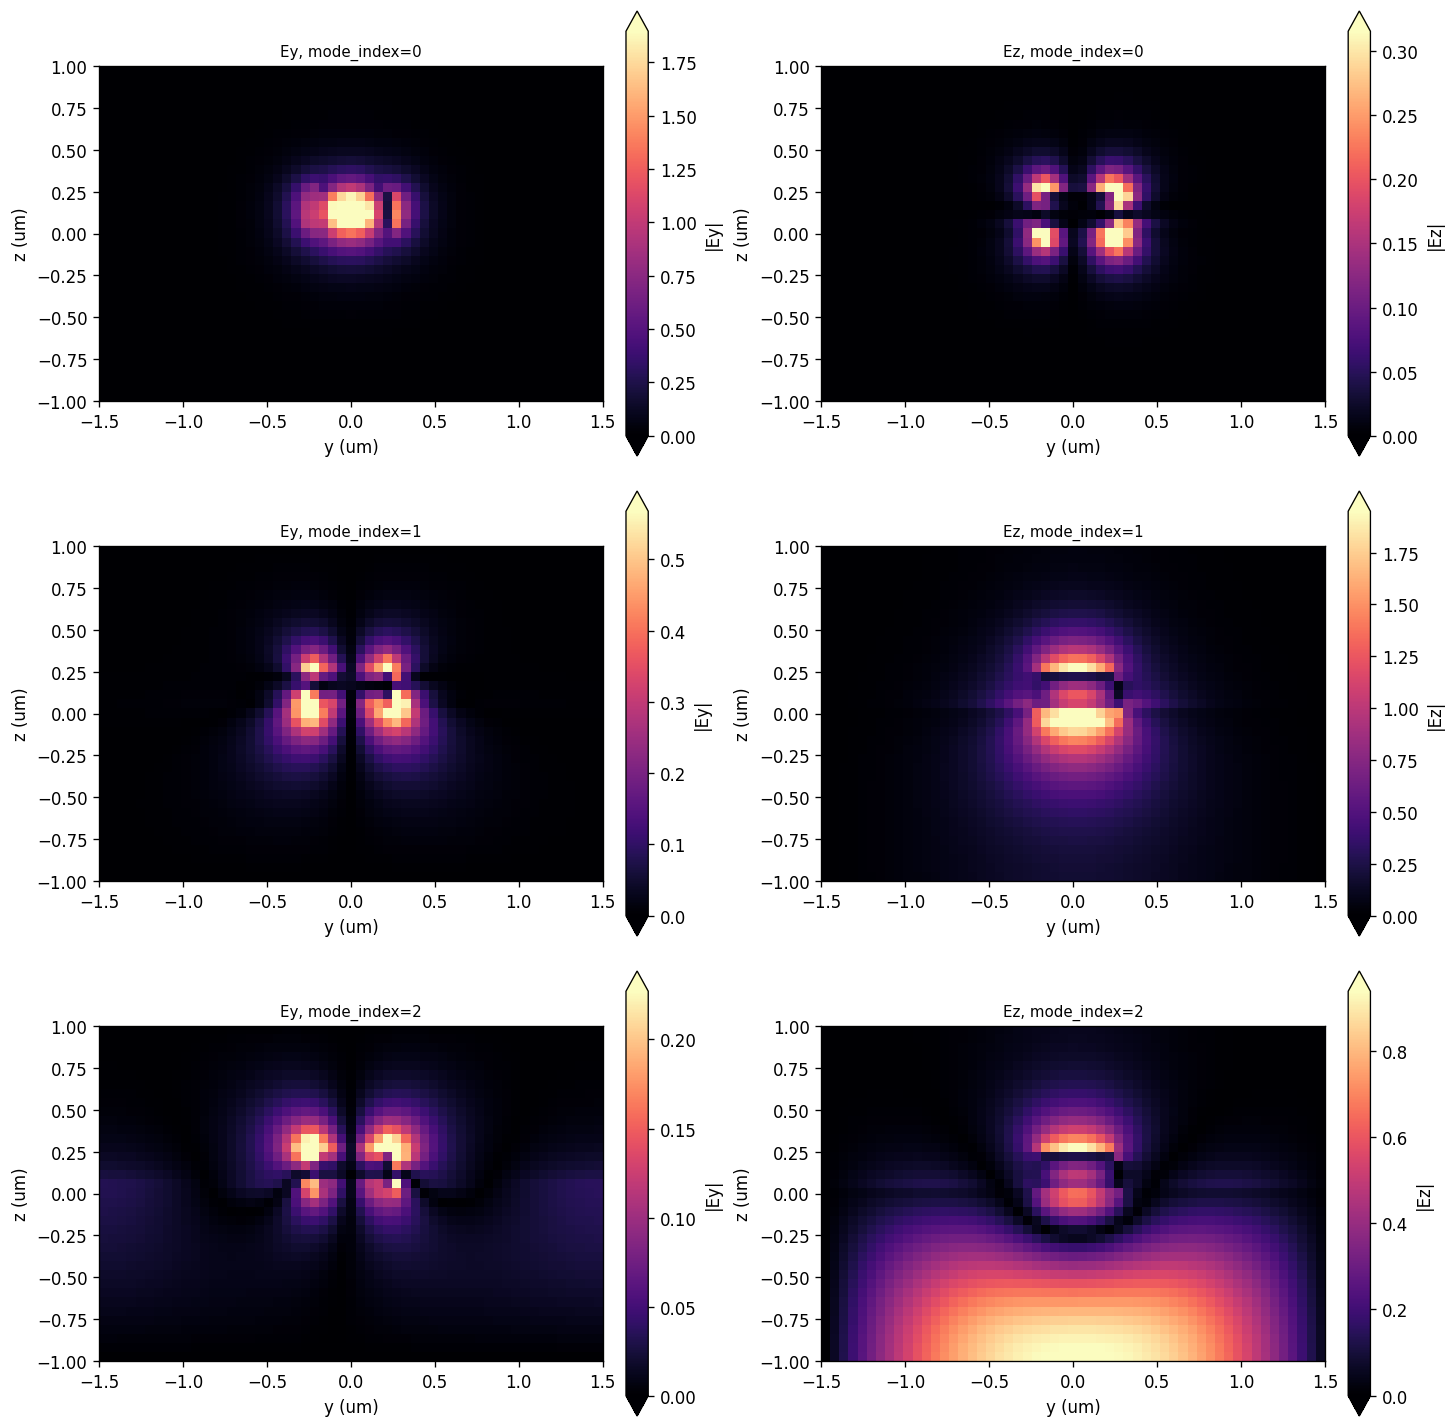

In [5]:
assert mode_spec.polarization is None, "Mode plots should use the unfiltered Tidy3D-style mode basis."
ms = bz.ModeSolver(simulation=sim0, plane=src_plane, mode_spec=mode_spec, freqs=[freq0])
modes = ms.solve()
fig, axes, neffs = ms.plot_field_components(
    field_names=("Ey", "Ez"),
    mode_indices=(0, 1, 2),
    val="abs",
    f=freq0,
    figsize=(12, 12),
    show=False,
)
display(modes.to_dataframe())
plt.show()

mode_source = ms.to_source(
    mode_index=0,
    direction="+",
    source_time=source_time,
    polarization=source_polarization,
    power=1.0,
)
sim = sim0.copy(update={"sources": [mode_source]})

## Run the Straight Waveguide

In [6]:
sim_data = sim.run(progress=True)
print(f"completed {sim.current_step} FDTD steps")

● JIT compiling v0.3 packed FDTD program... done!
● Progress: 100% (9742/9742 steps)
completed 9742 FDTD steps


## In-Plane Field and Mode Decomposition

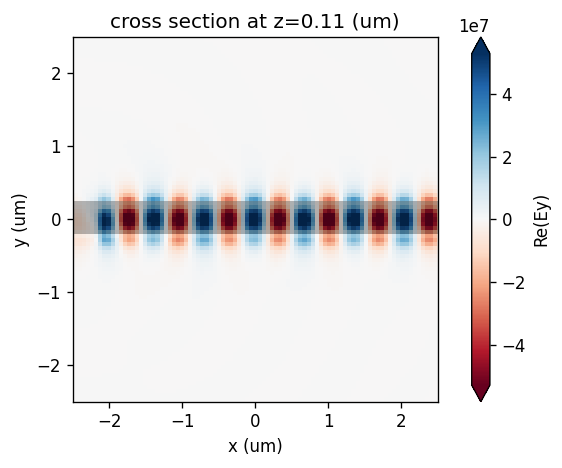

Flux at central frequency: 0.946840304028798
Power distribution at central frequency in first three modes
  positive dir. [9.12652096e-01 1.30593546e-03 6.07046861e-04]
  negative dir. [1.39105442e-05 7.25954498e-08 3.28998107e-05]


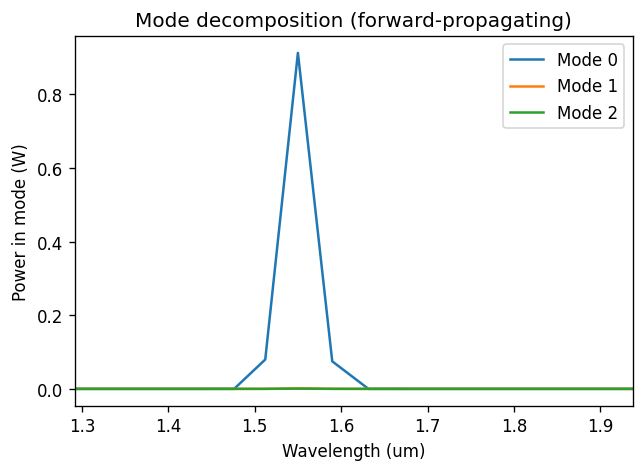

In [7]:
sim_data.plot_field("field", "Ey", frequency=freq0, val="real", cmap="RdBu", xlim=(-2.5, 2.5), ylim=(-2.5, 2.5))
plt.show()

flux_wg = sim_data["flux"].flux
mode_amps = sim_data["mode"]
coeffs_f = mode_amps.amps.sel(direction="+")
coeffs_b = mode_amps.amps.sel(direction="-")

print("Flux at central frequency:", float(flux_wg.isel(f=fcent_ind)))
print("Power distribution at central frequency in first three modes")
print("  positive dir.", np.abs(coeffs_f.isel(f=fcent_ind).values) ** 2)
print("  negative dir.", np.abs(coeffs_b.isel(f=fcent_ind).values) ** 2)

fig, ax = plt.subplots(1, figsize=(6, 4))
ax.plot(lambdas_um, np.abs(coeffs_f.values) ** 2)
ax.set_xlim([lambdas_um[-1], lambdas_um[0]])
ax.set_xlabel("Wavelength (um)")
ax.set_ylabel("Power in mode (W)")
ax.set_title("Mode decomposition (forward-propagating)")
ax.legend(["Mode 0", "Mode 1", "Mode 2"])
plt.show()

## Width-Step Junction

The junction variant reuses the same source and monitors, just as the Tidy3D tutorial updates the structure list.

● Done: Raster cache hit (3d): 1eaf0b1f7c4a74d49c2689d261b6b4d1189027fdc50daa4417c67fba149578ca.npz | load=0.14s


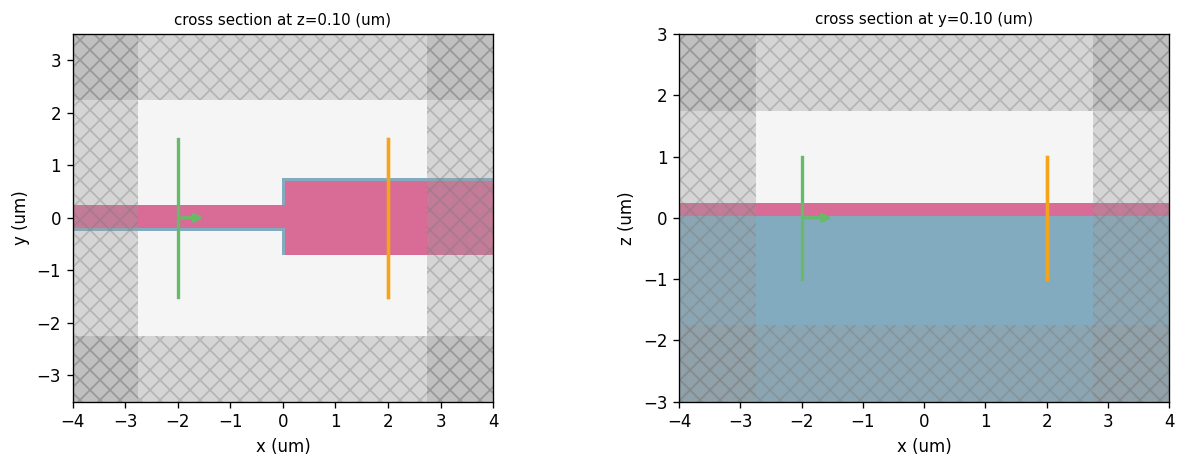

In [8]:
wgout_width = 1.4 * um
waveguide_out = bz.Structure(
    geometry=bz.Box(
        center=(0.25 * sim_size[0], 0, 0.5 * wg_height),
        size=(0.5 * sim_size[0], wgout_width, wg_height),
    ),
    medium=mat_wg,
)

sim_jct0 = bz.Simulation(
    size=sim_size,
    grid_spec=grid_spec,
    structures=[substrate, waveguide, waveguide_out],
    sources=[],
    monitors=[field_mnt, flux_mnt, mode_mnt],
    boundary_spec=boundary_spec,
    run_time=run_time,
)
sim_jct = sim_jct0.copy(update={"sources": [mode_source]})
fig, axes = sim_jct.plot(z=0.1 * um, y=0.1 * um, width_ratios=[1, 1.4], show=False)
plt.show()

In [9]:
sim_data_jct = sim_jct.run(progress=True)
print(f"completed {sim_jct.current_step} FDTD steps")

● JIT compiling v0.3 packed FDTD program... done!
● Progress: 100% (9742/9742 steps)
completed 9742 FDTD steps


## Junction Fields and Normalized Mode Powers

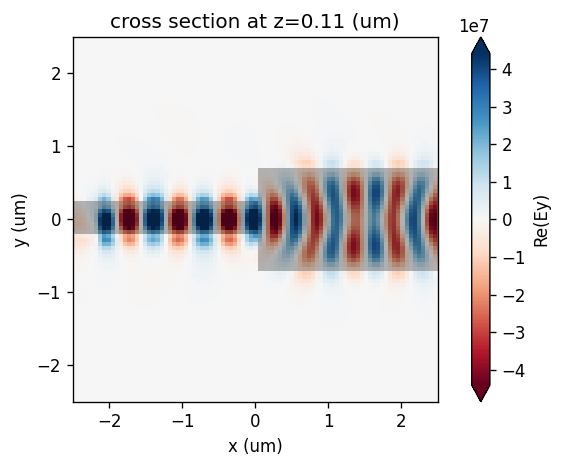

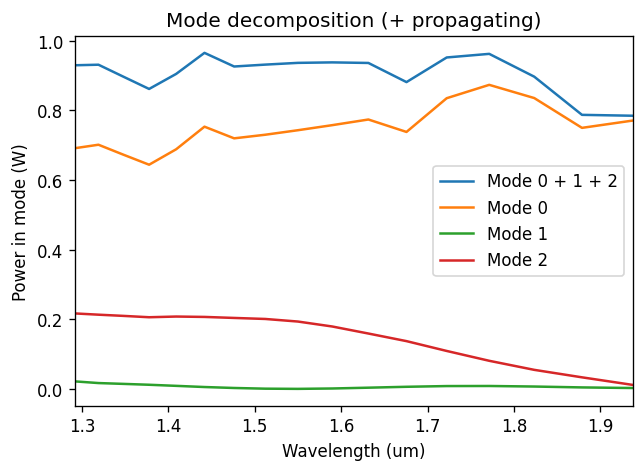

In [10]:
sim_data_jct.plot_field("field", "Ey", frequency=freq0, val="real", cmap="RdBu", xlim=(-2.5, 2.5), ylim=(-2.5, 2.5))
plt.show()

amps_jct = sim_data_jct["mode"].amps.sel(direction="+")
amps_jct = amps_jct / np.sqrt(np.maximum(flux_wg.values, 1e-18))[:, None]

fig, ax = plt.subplots(1, figsize=(6, 4))
ax.plot(lambdas_um, np.sum(np.abs(amps_jct.values) ** 2, axis=1))
ax.plot(lambdas_um, np.abs(amps_jct.values) ** 2)
ax.set_xlim([lambdas_um[-1], lambdas_um[0]])
ax.set_xlabel("Wavelength (um)")
ax.set_ylabel("Power in mode (W)")
ax.set_title("Mode decomposition (+ propagating)")
ax.legend(["Mode 0 + 1 + 2", "Mode 0", "Mode 1", "Mode 2"])
plt.show()

## Summary

The notebook now follows the same semantic steps as the Tidy3D tutorial: define structures and monitors, solve the source mode, convert it to a source, run, and index named result data.